In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline
print(" All imports done")

 All imports done


In [6]:
df = pd.read_csv("../data/raw/telco_churn.csv")

print("Shape:", df.shape)
print("\nFirst look:")
df.head()

Shape: (7043, 21)

First look:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Nulls created: {df['TotalCharges'].isnull().sum()}")
df['TotalCharges'].fillna(df['MonthlyCharges'], inplace=True)
print(f"Nulls after fix: {df['TotalCharges'].isnull().sum()}")
print(f"TotalCharges dtype now: {df['TotalCharges'].dtype}")

Nulls created: 11
Nulls after fix: 0
TotalCharges dtype now: float64


In [8]:
print("=== SHAPE ===")
print(df.shape)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n=== DUPLICATES ===")
print(f"Duplicate rows: {df.duplicated().sum()}")

print("\n=== TARGET DISTRIBUTION ===")
churn_counts = df['Churn'].value_counts()
print(churn_counts)
print(f"\nChurn rate: {df['Churn'].eq('Yes').mean()*100:.2f}%")


=== SHAPE ===
(7043, 21)

=== MISSING VALUES ===
Series([], dtype: int64)

=== DUPLICATES ===
Duplicate rows: 0

=== TARGET DISTRIBUTION ===
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.54%


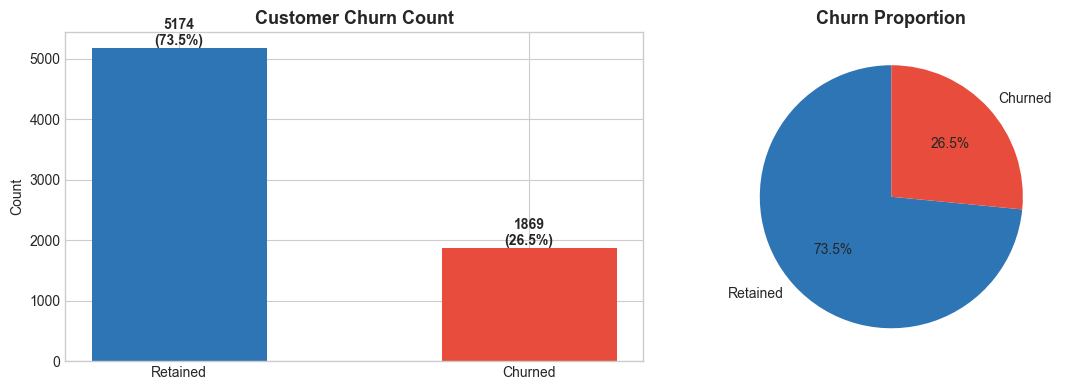

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Churn'].value_counts()

axes[0].bar(['Retained', 'Churned'], counts.values, 
            color=['#2E75B6', '#E74C3C'], width=0.5)
axes[0].set_title('Customer Churn Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+50, f'{v}\n({v/len(df)*100:.1f}%)', 
                 ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Retained', 'Churned'],
            autopct='%1.1f%%', colors=['#2E75B6', '#E74C3C'], startangle=90)
axes[1].set_title('Churn Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
import sqlite3

conn = sqlite3.connect(":memory:")
df.to_sql("customers", conn, if_exists="replace", index=False)

# Query 1: Churn by contract type
q1 = pd.read_sql_query("""
    SELECT Contract,
           COUNT(*) AS total,
           SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS churned,
           ROUND(SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*), 2) AS churn_pct
    FROM customers
    GROUP BY Contract
    ORDER BY churn_pct DESC
""", conn)
print(" Churn by Contract:\n", q1.to_string(index=False))

# Query 2: Churn by tenure group
q2 = pd.read_sql_query("""
    SELECT CASE
               WHEN tenure BETWEEN 0  AND 12 THEN '0-12 months'
               WHEN tenure BETWEEN 13 AND 24 THEN '13-24 months'
               WHEN tenure BETWEEN 25 AND 48 THEN '25-48 months'
               ELSE '49+ months'
           END AS tenure_group,
           COUNT(*) AS total,
           ROUND(SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*), 2) AS churn_pct
    FROM customers
    GROUP BY tenure_group
    ORDER BY churn_pct DESC
""", conn)
print("\n Churn by Tenure Group:\n", q2.to_string(index=False))

# Query 3: Revenue at risk
q3 = pd.read_sql_query("""
    SELECT Contract,
           COUNT(*) AS churned_customers,
           ROUND(SUM(MonthlyCharges), 2) AS monthly_revenue_at_risk
    FROM customers
    WHERE Churn = 'Yes'
    GROUP BY Contract
    ORDER BY monthly_revenue_at_risk DESC
""", conn)
print("\n Revenue at Risk:\n", q3.to_string(index=False))

# Query 4: High risk customers
q4 = pd.read_sql_query("""
    SELECT customerID, tenure, MonthlyCharges, Contract, Churn
    FROM customers
    WHERE Contract = 'Month-to-month'
      AND tenure < 12
      AND MonthlyCharges > 65
    ORDER BY MonthlyCharges DESC
    LIMIT 10
""", conn)
print("\n  High Risk Customers (sample):\n", q4.to_string(index=False))

 Churn by Contract:
       Contract  total  churned  churn_pct
Month-to-month   3875     1655      42.71
      One year   1473      166      11.27
      Two year   1695       48       2.83

 Churn by Tenure Group:
 tenure_group  total  churn_pct
 0-12 months   2186      47.44
13-24 months   1024      28.71
25-48 months   1594      20.39
  49+ months   2239       9.51

 Revenue at Risk:
       Contract  churned_customers  monthly_revenue_at_risk
Month-to-month               1655                120847.10
      One year                166                 14118.45
      Two year                 48                  4165.30

  High Risk Customers (sample):
 customerID  tenure  MonthlyCharges       Contract Churn
3292-PBZEJ      11          111.40 Month-to-month    No
9851-KIELU      10          110.10 Month-to-month   Yes
3992-YWPKO       6          109.90 Month-to-month   Yes
5760-IFJOZ       3          107.95 Month-to-month    No
2081-VEYEH       3          107.95 Month-to-month    No
1400

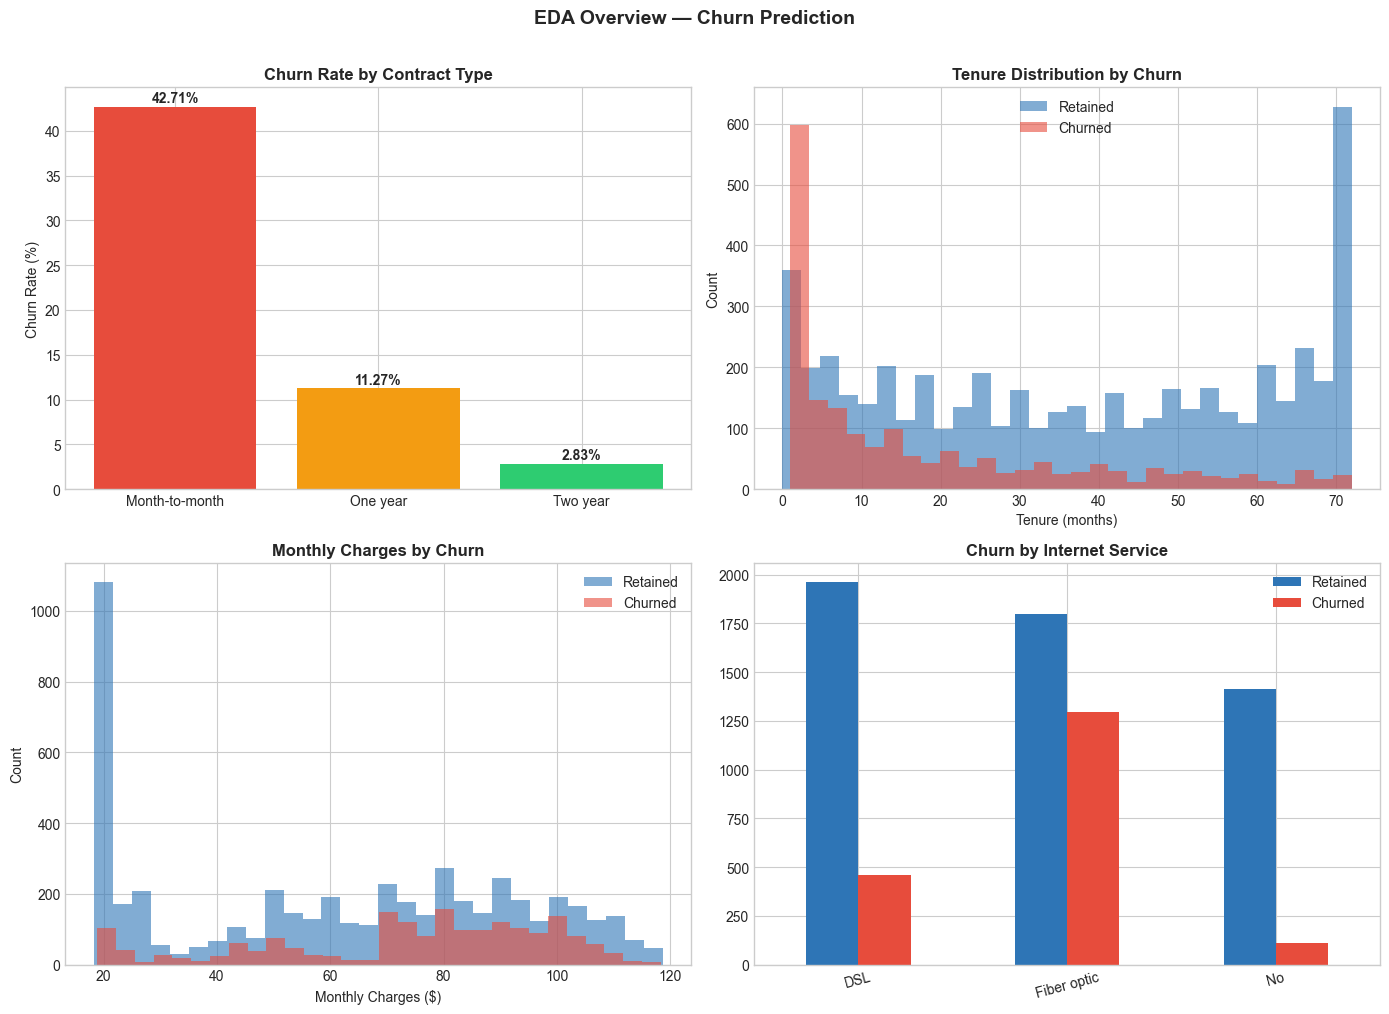

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Churn by contract
axes[0,0].bar(q1['Contract'], q1['churn_pct'], 
              color=['#E74C3C', '#F39C12', '#2ECC71'])
axes[0,0].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[0,0].set_ylabel('Churn Rate (%)')
for bar, val in zip(axes[0,0].patches, q1['churn_pct']):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, 
                   bar.get_height()+0.5, f'{val}%', 
                   ha='center', fontweight='bold')

# Plot 2: Tenure distribution
axes[0,1].hist(df[df['Churn']=='No']['tenure'], alpha=0.6, 
               label='Retained', color='#2E75B6', bins=30)
axes[0,1].hist(df[df['Churn']=='Yes']['tenure'], alpha=0.6, 
               label='Churned', color='#E74C3C', bins=30)
axes[0,1].set_title('Tenure Distribution by Churn', fontweight='bold')
axes[0,1].set_xlabel('Tenure (months)')
axes[0,1].set_ylabel('Count')
axes[0,1].legend()

# Plot 3: Monthly charges distribution
axes[1,0].hist(df[df['Churn']=='No']['MonthlyCharges'], alpha=0.6,
               label='Retained', color='#2E75B6', bins=30)
axes[1,0].hist(df[df['Churn']=='Yes']['MonthlyCharges'], alpha=0.6,
               label='Churned', color='#E74C3C', bins=30)
axes[1,0].set_title('Monthly Charges by Churn', fontweight='bold')
axes[1,0].set_xlabel('Monthly Charges ($)')
axes[1,0].set_ylabel('Count')
axes[1,0].legend()

# Plot 4: Churn by internet service
internet_churn = df.groupby(['InternetService', 'Churn']).size().unstack()
internet_churn.plot(kind='bar', ax=axes[1,1], 
                    color=['#2E75B6', '#E74C3C'])
axes[1,1].set_title('Churn by Internet Service', fontweight='bold')
axes[1,1].set_xlabel('')
axes[1,1].tick_params(axis='x', rotation=15)
axes[1,1].legend(['Retained', 'Churned'])

plt.suptitle('EDA Overview — Churn Prediction', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/02_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

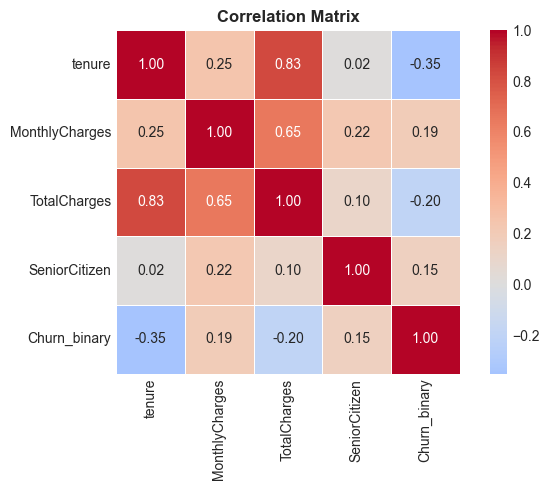

In [14]:
df_corr = df.copy()
df_corr['Churn_binary'] = (df_corr['Churn'] == 'Yes').astype(int)

corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_binary']
corr = df_corr[corr_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
df.to_csv('../data/processed/telco_cleaned.csv', index=False)

print("✅ Notebook 1 Complete!")
print("="*45)
print(f"  Total customers:          {len(df):,}")
print(f"  Churn rate:               26.54%")
print(f"  Avg tenure (churned):     {df[df['Churn']=='Yes']['tenure'].mean():.1f} months")
print(f"  Avg tenure (retained):    {df[df['Churn']=='No']['tenure'].mean():.1f} months")
print(f"  Avg charges (churned):    ${df[df['Churn']=='Yes']['MonthlyCharges'].mean():.2f}")
print(f"  Avg charges (retained):   ${df[df['Churn']=='No']['MonthlyCharges'].mean():.2f}")
print("="*45)
print("\nFiles saved:")
print("  outputs/01_churn_distribution.png")
print("  outputs/02_eda_overview.png")
print("  outputs/03_correlation_heatmap.png")
print("  data/processed/telco_cleaned.csv")

✅ Notebook 1 Complete!
  Total customers:          7,043
  Churn rate:               26.54%
  Avg tenure (churned):     18.0 months
  Avg tenure (retained):    37.6 months
  Avg charges (churned):    $74.44
  Avg charges (retained):   $61.27

Files saved:
  outputs/01_churn_distribution.png
  outputs/02_eda_overview.png
  outputs/03_correlation_heatmap.png
  data/processed/telco_cleaned.csv
